<a href="https://colab.research.google.com/github/mesheetos/Bounds-on-Loss-Tangent-Final-Code/blob/main/Springer_Figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
%pip install numpy scipy matplotlib sympy cvxpy clarabel pillow

In [10]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial as Poly
from scipy.spatial import ConvexHull
from matplotlib.ticker import MaxNLocator

# Illustrative dimensionless parameters, not experimental measurements.
L, M, V, RHO = 0.10, 0.50, 0.04, 0.20

OUT = Path("maxwell_figures_output")
OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

BLUE, RED = "#2166ac", "#b2182b"


def two(u, l=L, m=M, v=V):
    x = np.array([u, m + v / (m - u)])
    w = np.array([v, (m - u)**2]) / (v + (m - u)**2)
    return x, w


def three(c, l=L, m=M, v=V):
    x = np.array([l, c, 1.0])
    w = np.array([
        (v + (1 - m) * (c - m)) / ((c - l) * (1 - l)),
        ((m - l) * (1 - m) - v) / ((c - l) * (1 - c)),
        (v + (m - l) * (m - c)) / ((1 - l) * (1 - c)),
    ])
    return x, w


def response(z, x, w, rho=RHO):
    y = np.asarray(z)[..., None] * x
    a = np.sum(w * y * y / (1 + y * y), axis=-1)
    b = np.sum(w * y / (1 + y * y), axis=-1)
    return a, b, b / (rho + a)


def real_roots(coeff):
    coeff = np.asarray(coeff, float)
    coeff /= np.max(np.abs(coeff))
    return [
        r.real for r in Poly(coeff).roots()
        if abs(r.imag) < 1e-9
    ]


def solve(z, l=L, m=M, v=V, rho=RHO):
    assert 0 < l < 1 and l <= m <= 1 and rho > 0 and z > 0

    vmax = (m - l) * (1 - m)
    assert 0 <= v <= vmax

    if v == 0 or v == vmax:
        if v == 0:
            x, w = np.array([m]), np.array([1.])
        else:
            x = np.array([l, 1.])
            w = np.array([(1 - m) / (1 - l), (m - l) / (1 - l)])

        rec = dict(
            x=x,
            w=w,
            t=float(response(z, x, w, rho)[2]),
            kind="boundary",
        )
        return rec, rec

    s2 = m * m + v
    cm, cp = m - v / (1 - m), m + v / (m - l)
    sl, sr = l + cp, cm + 1
    candidates = []

    def add(x, w, q, kind):
        a, b, t = response(z, x, w, rho)
        q = Poly(q)
        p = Poly([1, 0, z * z]) * q + Poly([0, -z, t * z * z])

        # Check endpoints and  real interior stationary points
        crit = [l, 1.] + [
            r.real for r in p.deriv().roots()
            if abs(r.imag) < 1e-8 and l < r.real < 1
        ]
        vals = p(crit)
        scale = max(1., np.sum(np.abs(p.coef)))
        tol = 2e-9 * scale

        err = max(
            abs(w.sum() - 1),
            abs(w @ x - m),
            abs(w @ (x * x) - s2),
        )
        assert err < 2e-10 and w.min() > -2e-10
        assert x.min() >= l - 1e-10 and x.max() <= 1 + 1e-10

        moment_error = abs(q.coef @ np.array([1, m, s2]) - rho * t)
        assert moment_error < 2e-8 * max(1, np.sum(abs(q.coef)))
        assert max(abs(p(x))) < tol

        candidates.append(dict(
            x=x,
            w=w,
            t=float(t),
            q=q,
            p=p,
            kind=kind,
            moment_error=moment_error,
            min_p=float(min(vals)),
            max_p=float(max(vals)),
        ))

    for u, e, r, kind in [
        (l, l, cp, "left endpoint"),
        (cm, 1., cm, "right endpoint"),
    ]:
        x, w = two(u, l, m, v)
        t = float(response(z, x, w, rho)[2])

        def f(h):
            return (z * h - t * z * z * h * h) / (1 + z * z * h * h)

        fp = (
            (z - 2 * t * z * z * r - z**3 * r * r)
            / (1 + z * z * r * r)**2
        )
        alpha = (f(e) - f(r) - fp * (e - r)) / (e - r)**2

        add(
            x, w,
            [f(r) - fp * r + alpha * r * r,
             fp - 2 * alpha * r,
             alpha],
            kind,
        )

    f2 = [
        -((2 * rho + 1) * s2 + rho / z**2
          + (rho + 1) * z * z * s2 * s2),
        2 * (rho + 1) * m * (1 + z * z * s2),
        rho - (rho + 1) * z * z * m * m,
    ]

    for S in real_roots(f2):
        if sl + 1e-10 < S < sr - 1e-10:
            p = m * S - s2
            if abs(z * z * p - 1) < 1e-12:
                continue

            k = z**3 / (2 * S * (z * z * p - 1))
            u = (S - np.sqrt((S - 2 * m)**2 + 4 * v)) / 2
            x, w = two(u, l, m, v)

            add(
                x, w,
                [k * p * p, -2 * k * S / z**2, k / z**2],
                "two interior",
            )

    f3 = [
        m * (1 + l) - s2 + rho * l - rho / z**2,
        2 * (m + rho * (1 + l)),
        rho - (1 + rho) * z * z * l,
    ]

    for c in real_roots(f3):
        if cm + 1e-10 < c < cp - 1e-10:
            A = 1 + l + 2 * c
            C = (1 + l) * c * c + 2 * l * c
            if abs(A - z * z * C) < 1e-12:
                continue

            k = z**3 / (A - z * z * C)
            x, w = three(c, l, m, v)

            add(
                x, w,
                [-k * l * c * c, k * A / z**2, -k / z**2],
                "three atoms",
            )

    lo = min(candidates, key=lambda d: d["t"])
    hi = max(candidates, key=lambda d: d["t"])

    for rec, sgn in [(lo, -1), (hi, 1)]:
        p = rec["p"]
        scale = max(1, np.sum(abs(p.coef)))
        wrong = -rec["min_p"] if sgn == 1 else rec["max_p"]

        assert wrong <= 2e-9 * scale, (z, rec["kind"], wrong)

        rec["certificate_error_bound"] = (
            max(0, wrong) / (1 + z * z * l * l)
            + rec["moment_error"]
        ) / rho

    assert lo["t"] <= hi["t"] + 1e-12
    return lo, hi


def finish(fig, name):
    fig.savefig(OUT / (name + ".png"), dpi=240, bbox_inches="tight")
    fig.savefig(OUT / (name + ".svg"), bbox_inches="tight")
    plt.show()
    print(
        name
        + str(OUT)
    )

print("Setup ready")

Setup ready


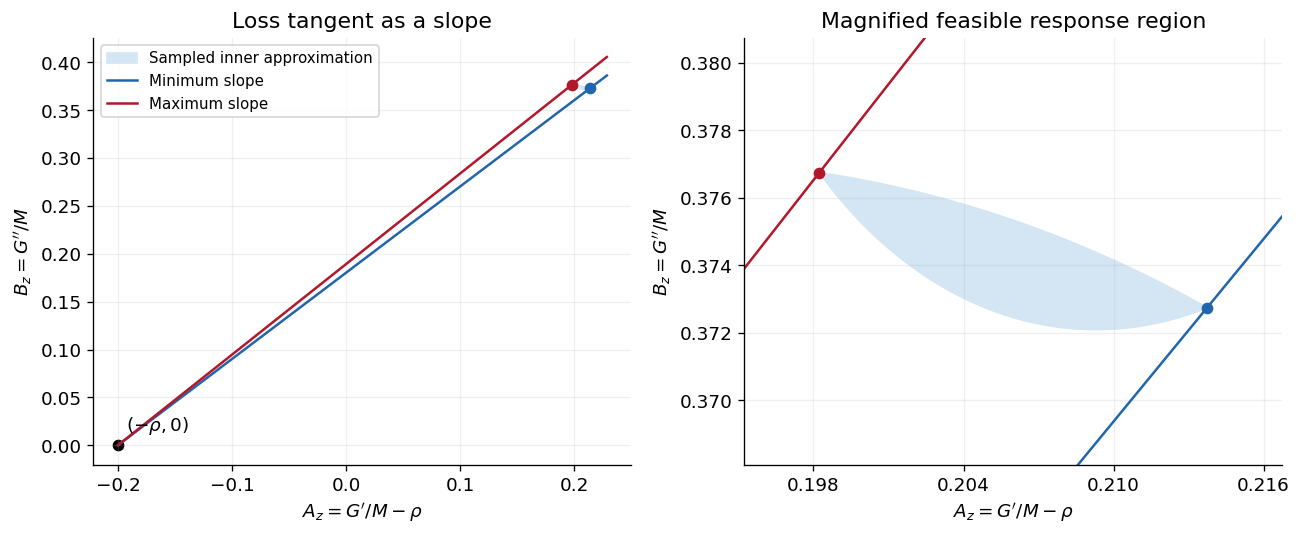

04_response_geometrymaxwell_figures_output


In [11]:
z = 1.
points = []

for u in np.linspace(L, M - V / (1 - M), 250):
    a, b, t = response(z, *two(u))
    points.append([a, b])

for c in np.linspace(M - V / (1 - M), M + V / (M - L), 250):
    a, b, t = response(z, *three(c))
    points.append([a, b])

lo, hi = solve(z)

for r in [lo, hi]:
    a, b, t = response(z, r["x"], r["w"])
    points.append([a, b])

points = np.array(points)

assert np.all(points[:, 1] >= lo["t"] * (RHO + points[:, 0]) - 1e-10)
assert np.all(points[:, 1] <= hi["t"] * (RHO + points[:, 0]) + 1e-10)

hull = ConvexHull(points)
poly = points[hull.vertices]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for j, ax in enumerate(axes):
    ax.fill(
        poly[:, 0], poly[:, 1],
        color="#d4e5f4",
        label="Sampled inner approximation",
    )

    ar = np.linspace(-RHO, points[:, 0].max() + .015, 300)

    for rec, color, label in [
        (lo, BLUE, "Minimum slope"),
        (hi, RED, "Maximum slope"),
    ]:
        ax.plot(ar, rec["t"] * (RHO + ar), color=color, label=label)
        a, b, t = response(z, rec["x"], rec["w"])
        ax.scatter(a, b, color=color, zorder=4)

    ax.set(
        xlabel=r"$A_z=G^\prime/M-\rho$",
        ylabel=r"$B_z=G^{\prime\prime}/M$",
    )
    ax.grid(alpha=.2)

    if j == 0:
        ax.scatter([-RHO], [0], color="black")
        ax.annotate(
            r"$(-\rho,0)$", (-RHO, 0),
            xytext=(5, 9), textcoords="offset points",
        )
        ax.set_title("Loss tangent as a slope")
        ax.legend(fontsize=9)
    else:
        ax.set(
            xlim=(points[:, 0].min() - .003, points[:, 0].max() + .003),
            ylim=(points[:, 1].min() - .004, points[:, 1].max() + .004),
            title="Magnified feasible response region",
        )

axes[1].xaxis.set_major_locator(MaxNLocator(4))
fig.tight_layout()
finish(fig, "01_response_geometry")

Lower certificate objective-error bound: 1.3877787807814457e-16
Upper certificate objective-error bound: 0.0


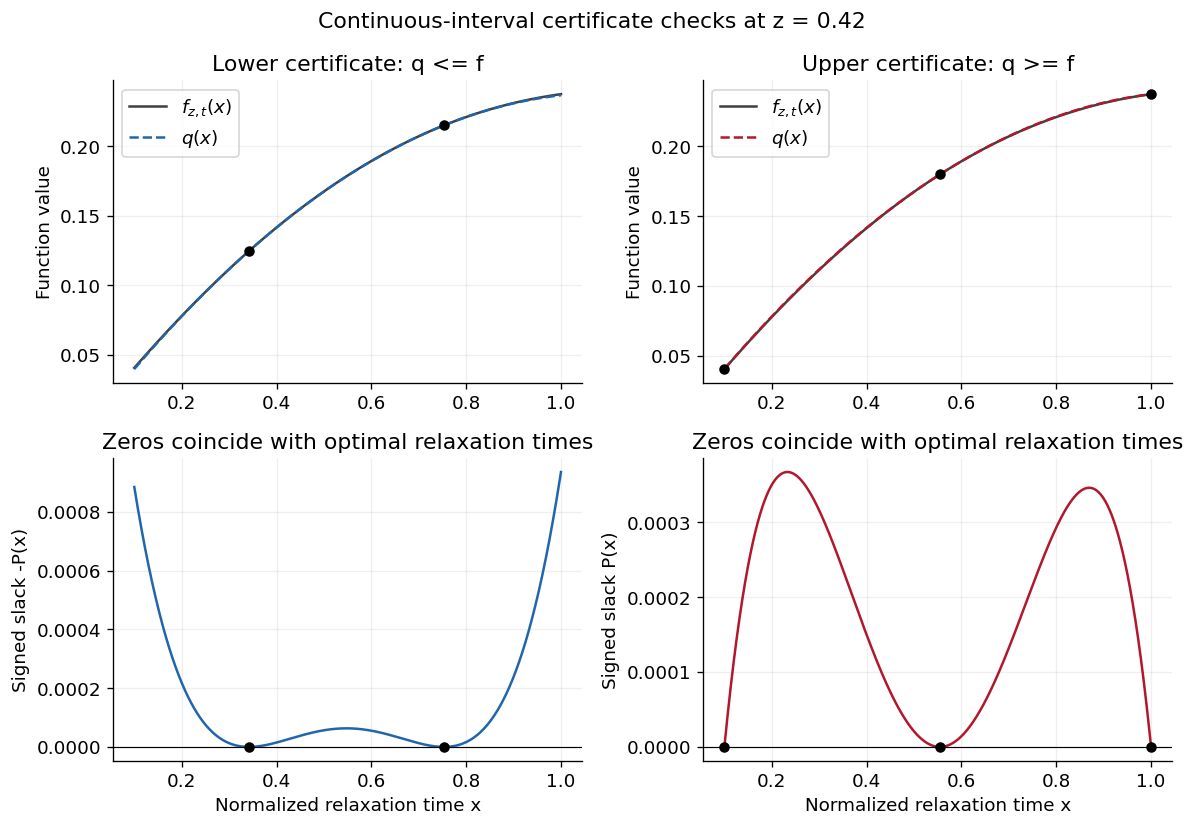

03_global_certificatesmaxwell_figures_output


In [12]:
z = .42
xx = np.linspace(L, 1, 1200)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for j, rec in enumerate(solve(z)):
    t = rec["t"]
    q = rec["q"]
    p = rec["p"]
    sign = [-1, 1][j]

    f = (z * xx - t * z * z * xx * xx) / (1 + z * z * xx * xx)

    ax = axes[0, j]
    ax.plot(xx, f, color="0.25", label=r"$f_{z,t}(x)$")
    ax.plot(xx, q(xx), "--", color=[BLUE, RED][j], label=r"$q(x)$")
    ax.scatter(rec["x"], q(rec["x"]), color="black", s=28, zorder=4)
    ax.set_title([
        "Lower certificate: q <= f",
        "Upper certificate: q >= f",
    ][j])
    ax.legend()
    ax.set_ylabel("Function value")

    ax = axes[1, j]
    ax.plot(xx, sign * p(xx), color=[BLUE, RED][j])
    ax.axhline(0, color="black", lw=.7)
    ax.scatter(
        rec["x"], np.zeros(len(rec["x"])),
        color="black", s=28, zorder=4,
    )
    ax.set(
        xlabel="Normalized relaxation time x",
        ylabel=["Signed slack -P(x)", "Signed slack P(x)"][j],
    )
    ax.set_title("Zeros coincide with optimal relaxation times")

    print(
        ["Lower", "Upper"][j],
        "certificate objective-error bound:",
        rec["certificate_error_bound"],
    )

for ax in axes.flat:
    ax.grid(alpha=.2)
fig.tight_layout()
finish(fig, "02_global_certificates")

z=0.1, min: x=[0.42 1.  ], w=[0.86206897 0.13793103]
z=0.1, max: x=[0.1 0.6], w=[0.2 0.8]
z=0.42, min: x=[0.34194101 0.75307007], w=[0.61554898 0.38445102]
z=0.42, max: x=[0.1        0.55469613 1.        ], w=[0.16457405 0.79020952 0.04521644]
z=3, min: x=[0.1 0.6], w=[0.2 0.8]
z=3, max: x=[0.40594167 0.92526804], w=[0.81888398 0.18111602]


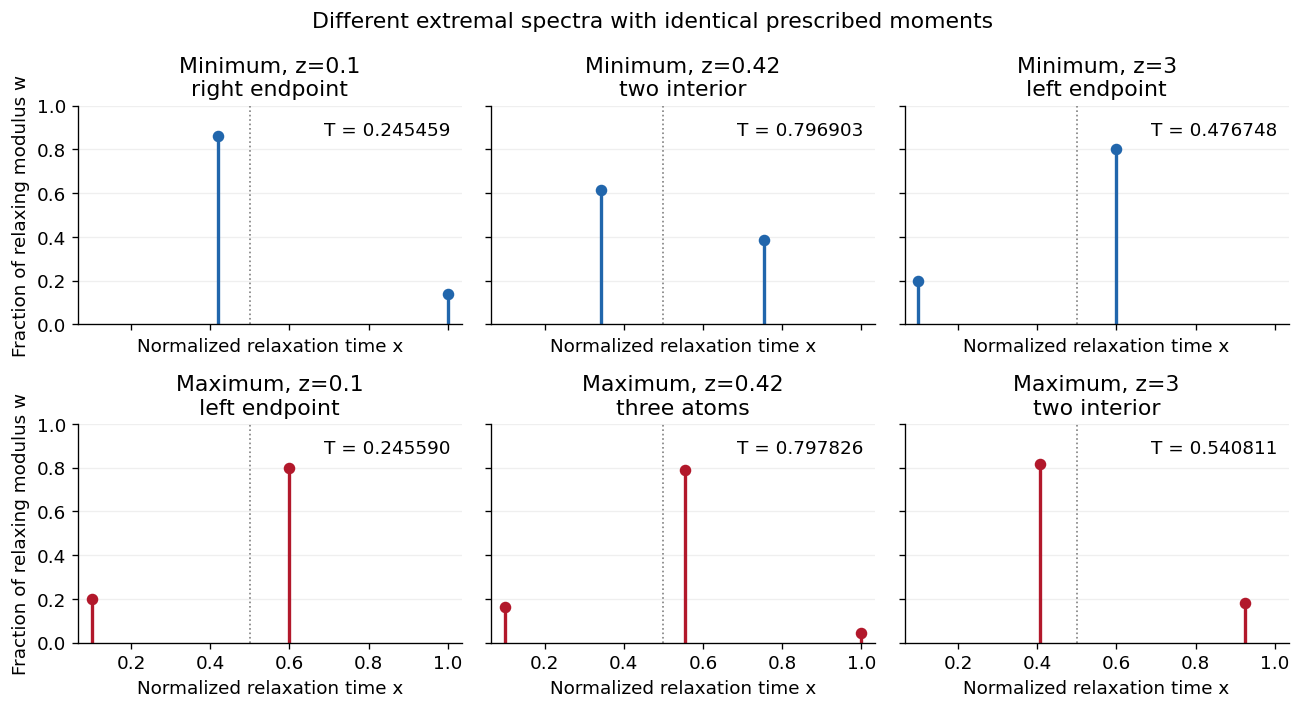

02_extremal_spectramaxwell_figures_output


In [13]:
zs = [.1, .42, 3.]
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=True)

for j, z in enumerate(zs):
    for i, rec in enumerate(solve(z)):
        ax = axes[i, j]
        color = [BLUE, RED][i]

        ax.vlines(rec["x"], 0, rec["w"], color=color, lw=2)
        ax.scatter(rec["x"], rec["w"], color=color, s=35, zorder=3)
        ax.axvline(M, color="0.5", ls=":", lw=1)

        ax.set_title(
            ("Minimum" if i == 0 else "Maximum")
            + f", z={z:g}\n"
            + rec["kind"]
        )
        ax.set(
            xlim=(L - .035, 1.035),
            ylim=(0, 1),
            xlabel="Normalized relaxation time x",
        )

        if j == 0:
            ax.set_ylabel("Fraction of relaxing modulus w")

        ax.text(
            .97, .93, f"T = {rec['t']:.6f}",
            ha="right", va="top", transform=ax.transAxes,
        )
        ax.grid(axis="y", alpha=.2)

        print(
            f"z={z:g}, {['min', 'max'][i]}: "
            f"x={rec['x']}, w={rec['w']}"
        )

fig.suptitle("Different extremal spectra with identical prescribed moments")
fig.tight_layout()
finish(fig, "03_extremal_spectra")

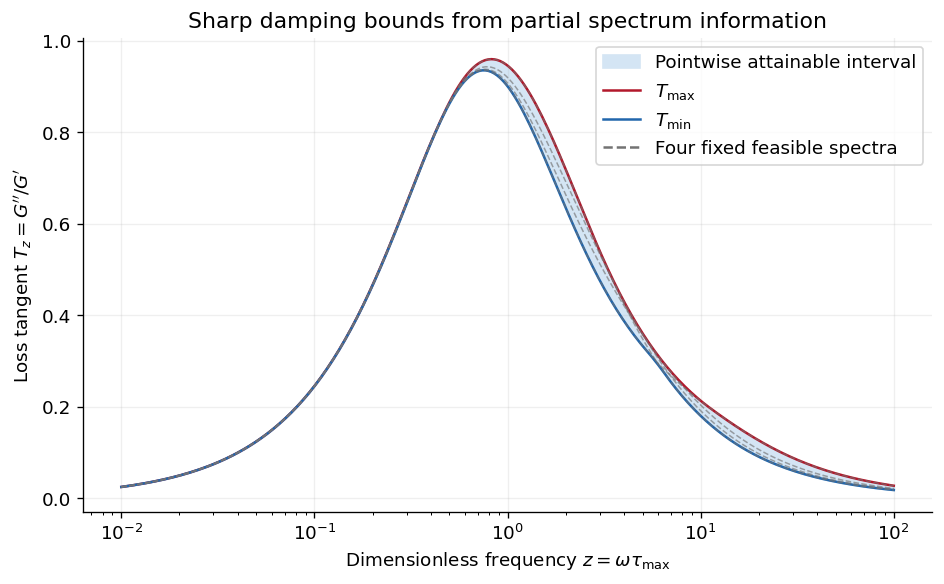

01_sharp_boundsmaxwell_figures_output


In [14]:
z = np.geomspace(.01, 100, 260)
sol = [solve(a) for a in z]

low = np.array([a["t"] for a, b in sol])
high = np.array([b["t"] for a, b in sol])

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(
    z, low, high,
    color="#d4e5f4",
    label="Pointwise attainable interval",
)
ax.plot(z, high, color=RED, label=r"$T_{\max}$")
ax.plot(z, low, color=BLUE, label=r"$T_{\min}$")

for u in np.linspace(L, M - V / (1 - M), 4):
    x, w = two(u)
    t = response(z, x, w)[2]

    assert np.all(t >= low - 1e-10)
    assert np.all(t <= high + 1e-10)

    ax.plot(z, t, "--", color="0.45", lw=.9, alpha=.65)

ax.plot([], [], "--", color="0.45", label="Four fixed feasible spectra")

ax.set(
    xscale="log",
    xlabel=r"Dimensionless frequency $z=\omega\tau_{\max}$",
    ylabel=r"Loss tangent $T_z=G^{\prime\prime}/G^{\prime}$",
    title="Sharp damping bounds from partial spectrum information",
)
ax.legend()
ax.grid(alpha=.2)

fig.tight_layout()
finish(fig, "04_sharp_bounds")

Numerically checked support-pattern counts: {'right endpoint': 294, 'left endpoint': 294, 'two interior': 112, 'three atoms': 20}


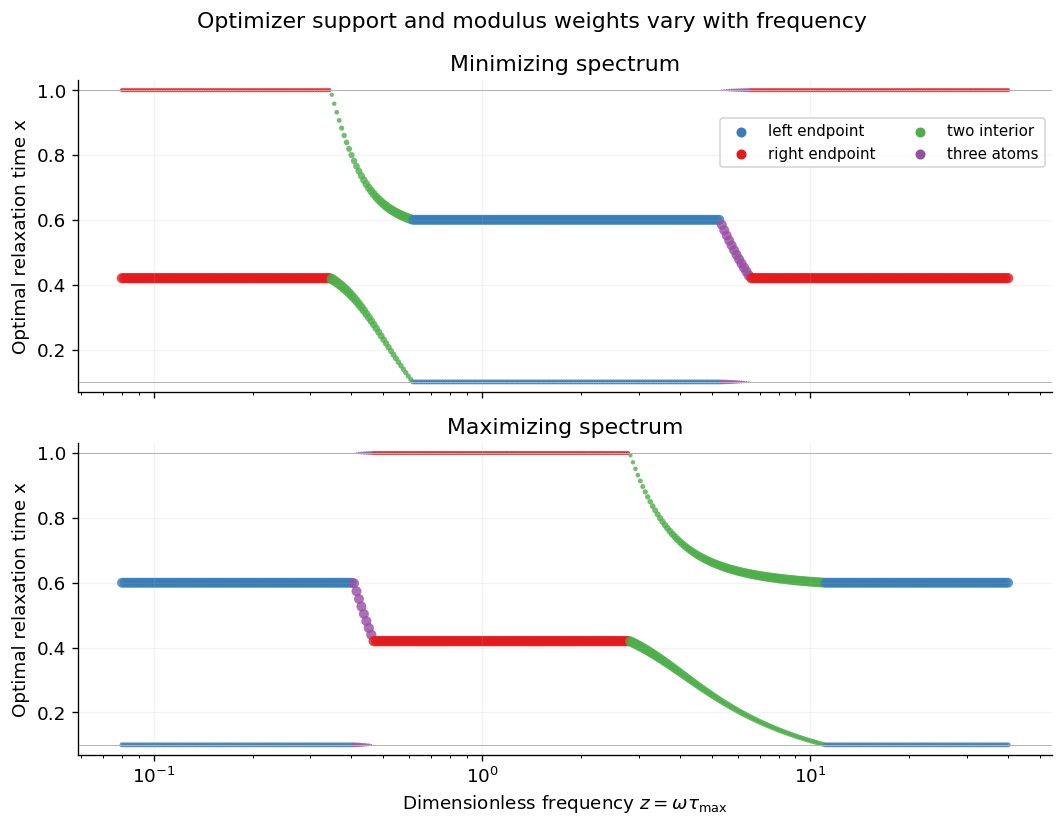

05_optimizer_transitionsmaxwell_figures_output


In [15]:
z = np.geomspace(.08, 40, 360)
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

colors = {
    "left endpoint": "#377eb8",
    "right endpoint": "#e41a1c",
    "two interior": "#4daf4a",
    "three atoms": "#984ea3",
}
counts = {}

for zz in z:
    for i, rec in enumerate(solve(zz)):
        axes[i].scatter(
            np.full(len(rec["x"]), zz),
            rec["x"],
            s=45 * rec["w"],
            color=colors[rec["kind"]],
            alpha=.8,
            linewidths=0,
        )
        counts[rec["kind"]] = counts.get(rec["kind"], 0) + 1

for i, ax in enumerate(axes):
    ax.axhline(L, color="0.7", lw=.6)
    ax.axhline(1, color="0.7", lw=.6)
    ax.set(
        xscale="log",
        ylim=(L - .03, 1.03),
        ylabel="Optimal relaxation time x",
        title=["Minimizing spectrum", "Maximizing spectrum"][i],
    )
    ax.grid(alpha=.15)

for kind, color in colors.items():
    axes[0].scatter([], [], color=color, s=25, label=kind)

axes[0].legend(
    ncol=2, fontsize=9,
    loc="center right", bbox_to_anchor=(1, .80),
)
axes[1].set_xlabel(
    r"Dimensionless frequency $z=\omega\tau_{\max}$"
)

fig.suptitle("Optimizer support and modulus weights vary with frequency")
fig.tight_layout()

print("Numerically checked support-pattern counts:", counts)
finish(fig, "05_optimizer_transitions")

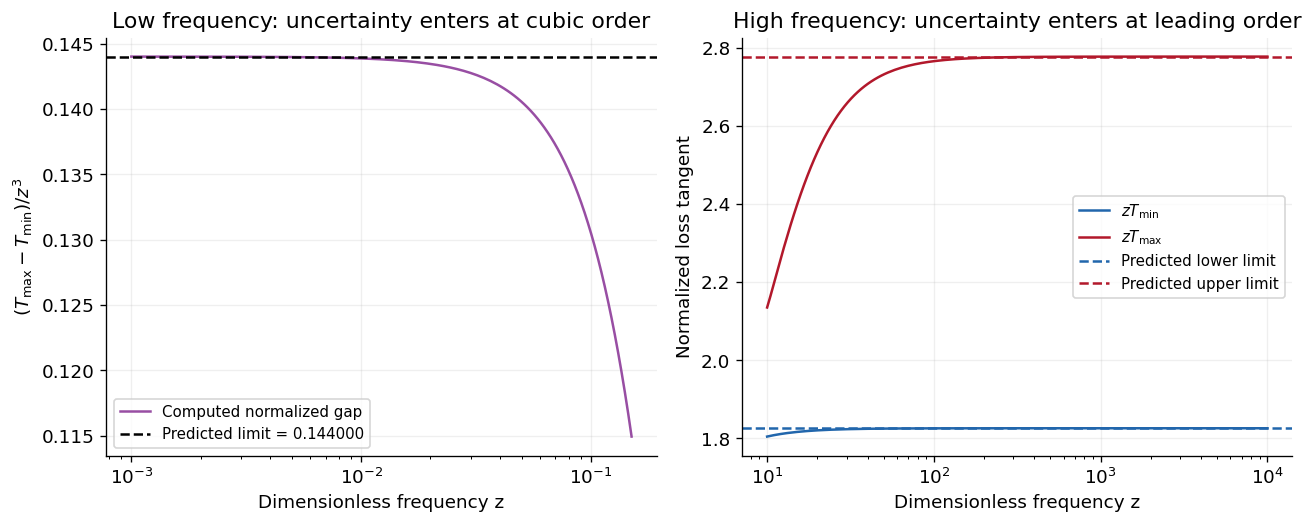

06_asymptotic_checksmaxwell_figures_output
Low-frequency relative error: 9.77085037334735e-06
High-frequency relative errors: 1.187485598741489e-08 4.259255718119803e-07


In [16]:
zlow = np.geomspace(.001, .15, 150)
zhigh = np.geomspace(10, 10000, 150)

lows = [solve(z) for z in zlow]
highs = [solve(z) for z in zhigh]

cubic = (
    V * (1 - L) / RHO
    * (1 - V / ((M - L) * (1 - M)))
)
gap = np.array([hi["t"] - lo["t"] for lo, hi in lows]) / zlow**3

xL, wL = two(L)
xR, wR = two(M - V / (1 - M))

eta_min = wR @ (1 / xR)
eta_max = wL @ (1 / xL)

hmin = np.array([lo["t"] for lo, hi in highs]) * zhigh
hmax = np.array([hi["t"] for lo, hi in highs]) * zhigh

assert abs(gap[0] / cubic - 1) < 1e-4
assert abs(hmin[-1] / (eta_min / (1 + RHO)) - 1) < 1e-5
assert abs(hmax[-1] / (eta_max / (1 + RHO)) - 1) < 1e-5

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(
    zlow, gap,
    color="#984ea3", label="Computed normalized gap",
)
axes[0].axhline(
    cubic, color="black", ls="--",
    label=f"Predicted limit = {cubic:.6f}",
)
axes[0].set(
    xscale="log",
    xlabel="Dimensionless frequency z",
    ylabel=r"$(T_{\max}-T_{\min})/z^3$",
    title="Low frequency: uncertainty enters at cubic order",
)

axes[1].plot(zhigh, hmin, color=BLUE, label=r"$zT_{\min}$")
axes[1].plot(zhigh, hmax, color=RED, label=r"$zT_{\max}$")
axes[1].axhline(
    eta_min / (1 + RHO),
    color=BLUE, ls="--", label="Predicted lower limit",
)
axes[1].axhline(
    eta_max / (1 + RHO),
    color=RED, ls="--", label="Predicted upper limit",
)
axes[1].set(
    xscale="log",
    xlabel="Dimensionless frequency z",
    ylabel="Normalized loss tangent",
    title="High frequency: uncertainty enters at leading order",
)

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(alpha=.2)

fig.tight_layout()
finish(fig, "06_asymptotic_checks")

print("Low-frequency relative error:", abs(gap[0] / cubic - 1))
print(
    "High-frequency relative errors:",
    abs(hmin[-1] / (eta_min / (1 + RHO)) - 1),
    abs(hmax[-1] / (eta_max / (1 + RHO)) - 1),
)